# DLMI Lecture 02

In this assingment you will ressample an image to change the voxel size.

In [1]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
import time 
import sys
import os 

First read the image.

In [2]:
engr_dir = "/opt/nfsopt/DLMI"
idas_dir = os.path.join(os.path.expanduser('~'), "classdata")

if os.path.isdir(engr_dir):
    data_dir = engr_dir
elif os.path.isdir(idas_dir):  
    data_dir = idas_dir
else:
    print("Data directory not found")
    
fn = os.path.join(data_dir, "lecture02", "CTChest.nii.gz")
im = sitk.ReadImage(fn)

Print the meta data below, what do you notice about spacing and size? Are the voxels isotropic?

In [7]:
print(
    f"Size: {im.GetSize()}\n"
    f"Spacing: {im.GetSpacing()}\n"
    f"Origin: {im.GetOrigin()}\n"
    f"Direction Cosine: {im.GetDirection()}"
)

print(f'Answer: Because the dimensions are not equal across all three axes,\n'
      f'the voxels are rectangular rather than a cube. Thus, the voxels are not isotopic')

Size: (512, 512, 139)
Spacing: (0.7617189884185791, 0.7617189884185791, 2.5)
Origin: (-195.0, -171.6999969482422, -347.75)
Direction Cosine: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Answer: Because the dimensions are not equal across all three axes,
the voxels are rectangular rather than a cube. Thus, the voxels are not isotopic


Compute the physical extent (mm) of the image.

In [39]:
######################################
#######         TODO           #######
######################################
size = np.array(im.GetSize())
spacing = np.array(im.GetSpacing())

physical_extent = size * spacing
print("Physical Extent (mm):", physical_extent)



Physical Extent (mm): [390.00012207 390.00012207 347.5       ]


Now, display the voxel matrix for a coronal slice in this notebook.  The voxel matrix (without metadata) is all that a neural network is given for input.

SimpleITK does not have an inline image viewer, however, we can convert the image to a NumPy array and then use the `imshow` function from the `matplotlib` package.

You can try changing the value of `cor_slc` to view different coronal slices.

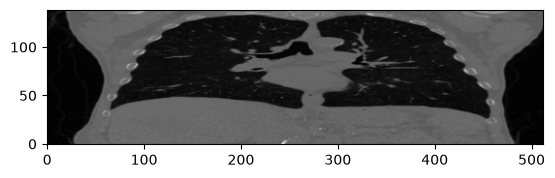

In [16]:
imnp = sitk.GetArrayFromImage(im)
cor_slc = 250  #200
plt.imshow(imnp[:,cor_slc,:], cmap = 'gray', origin = 'lower')

Note: in the above figure, axes units are in **voxels**, not physical distance

Open the same image in Slicer. View the coronal slice (green view). Use this as a reference for how the anatomy should appear (orientation and aspect ratio).  How does the imshow view compare to the Slicer view (answer below)?

### ANSWER: The IMShow image appears darker and more compact than the 3d Slicer option

Resample the image such that the voxels are 1 mm isotropic (i.e., 1 mm spacing in each dimension).

To do this will use the `sitk.ResampleImageFilter`

To perform resampling we need to define the output image meta data

Recall the field of view (FOV) remains fixed before and after resampling:  
 
 $\mathrm{FOV} = N_\mathrm{new} \times \Delta_\mathrm{new} = N_\mathrm{original} \times \Delta_\mathrm{original}$  
 
$N_\mathrm{original}$ and $\Delta_\mathrm{original.}$ are defined from the original input image. We set the desired output spacing $\Delta_\mathrm{new} = (1, 1, 1)$. This leaves  $N_\mathrm{new}$ to be calculated.

First, calculate the output image size $N_\mathrm{new}$ below:

Hint: $N_\mathrm{new}$ must be a **list of integers**, so you will need to round floating point values.

In [23]:
######################################
#######         TODO           #######
######################################

output_spacing = np.array([1.0, 1.0, 1.0])
output_size = np.round(size * spacing / output_spacing).astype(int)
print(f"output size: {output_size} \n" f"output spacing: {output_spacing}")

output size: [390 390 348] 
output spacing: [1. 1. 1.]


Now, create an instance of the `sitk.ResampleImageFilter` class and use the member functions to set the parameters for size, spacing, origin, direction, and interpolator. The resampled image will be stored in the `resampled_im` variable.

In [42]:
out_n = np.round((size - 1) * spacing / np.array(output_spacing)).astype(int) + 1

out_n = out_n = tuple(int(x) for x in out_n)

output_origin = im.GetOrigin()
output_direction = im.GetDirection()

In [43]:
resample = sitk.ResampleImageFilter()

# set size, output spacing, output origin, output direction, and interpolator
######################################
#######         TODO           #######
######################################
resample.SetOutputSpacing(output_spacing)
resample.SetSize(out_n)
resample.SetOutputOrigin(output_origin)
resample.SetOutputDirection(output_direction)
resample.SetInterpolator(sitk.sitkNearestNeighbor) #interpolator -- nearest neighbor

start_time = time.time()
resampled_im = resample.Execute(im)
print("Resample time : --- %s seconds ---" % (time.time() - start_time))

Resample time : --- 0.08270907402038574 seconds ---


Print the resampled images's metadata below:

In [44]:
######################################
#######         TODO           #######
######################################
print(f"Resampled Image\n"
    f"Size: {resampled_im.GetSize()}\n"
    f"Spacing: {resampled_im.GetSpacing()}\n"
    f"Origin: {resampled_im.GetOrigin()}\n"
    f"Direction Cosine: {resampled_im.GetDirection()}"
)

Resampled Image
Size: (390, 390, 346)
Spacing: (1.0, 1.0, 1.0)
Origin: (-195.0, -171.6999969482422, -347.75)
Direction Cosine: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


Display the voxel matrix for a coronal slice of the resampled image using `imshow`. Now that voxel spacing is isotropic, the aspect ratio of the voxel matrix will match that of physical reality. The voxel matrix (without metadata) now provides an accurate representation of the physical object to a neural network.

[[[-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  ...
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]]

 [[-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  ...
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]]

 [[-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  ...
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]]

 ...

 [[-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  [-3024 -3024 -3024 ... -3024 -3024 -3024]
  ...
  [-3024 -3024 -3024 ... -3024 -3024 -30

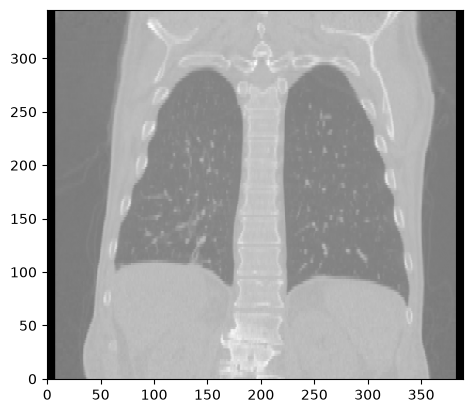

In [66]:
######################################
#######         TODO           #######
######################################

imnp_rs = sitk.GetArrayFromImage(resampled_im)
cor_slc_rs = 250  #200
plt.imshow(imnp_rs[:,cor_slc_rs,:], cmap = 'gray', origin = 'lower')
print(imnp_rs)


Below try resampling using different interpolators and displaying the result.
Here are some of the interpolators in SimpleITK:

`sitk.sitkNearestNeighbor`  
`sitk.sitkLinear`  
`sitk.sitkBSpline`  
`sitk.sitkGaussian`  
`sitk.sitkHammingWindowedSinc`  
`sitk.sitkCosineWindowedSinc`  

In [47]:
######################################
#######         TODO           #######
######################################
resample.SetInterpolator(sitk.sitkLinear) #interpolator -- Linear

start_timeLinear = time.time()
resampled_im_Linear = resample.Execute(im)
print("Resample time : --- %s seconds ---" % (time.time() - start_timeLinear))




Resample time : --- 0.17468881607055664 seconds ---


In [51]:
resample.SetInterpolator(sitk.sitkGaussian) #interpolator -- Gaussian

start_timeGaussian = time.time()
resampled_im_Gaussian = resample.Execute(im)
print("Resample time : --- %s seconds ---" % (time.time() - start_timeGaussian))

Resample time : --- 3.8002076148986816 seconds ---


In [54]:
resample.SetInterpolator(sitk.sitkBSpline) #interpolator -- BSpline

start_timeBSpline = time.time()
resampled_im_BSpline = resample.Execute(im)
print("Resample time : --- %s seconds ---" % (time.time() - start_timeBSpline))

Resample time : --- 4.412858724594116 seconds ---


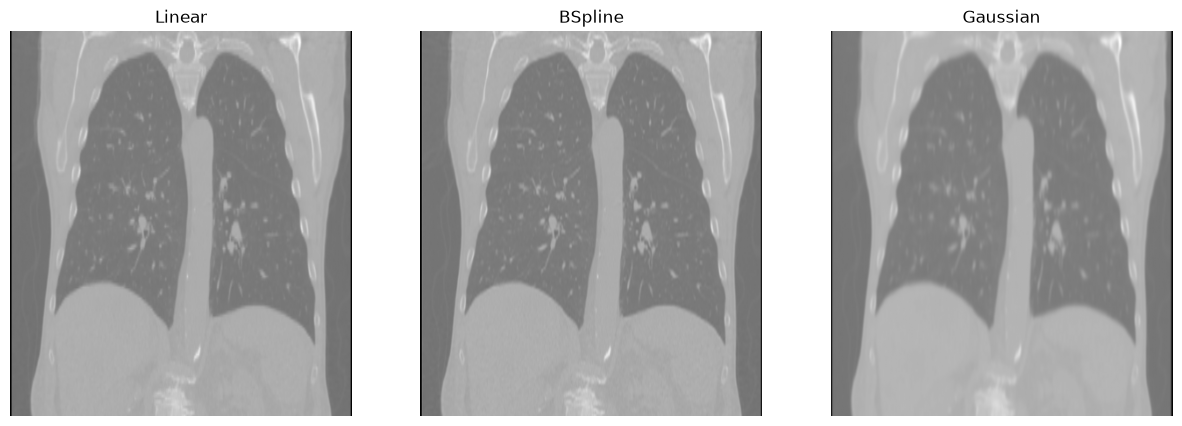

In [65]:
interpolators = {
    "Linear": sitk.sitkLinear,
    "BSpline": sitk.sitkBSpline,
    "Gaussian": sitk.sitkGaussian
}
outputs = {}

for name, interpolator in interpolators.items():

    resample = sitk.ResampleImageFilter()

    resample.SetOutputSpacing(output_spacing)
    resample.SetSize(out_n)
    resample.SetOutputOrigin(output_origin)
    resample.SetOutputDirection(output_direction)
    resample.SetInterpolator(interpolator)

    outputs[name] = resample.Execute(im)

slice_index = out_n[2] // 2

plt.figure(figsize=(15, 5))

for i, (name, img) in enumerate(outputs.items()):

    array = sitk.GetArrayFromImage(img)

    plt.subplot(1, 3, i + 1)
    plt.imshow(array[:,220,:], cmap = 'gray', origin = 'lower', aspect= 'auto', extent = 'right')
    plt.title(name)
    plt.axis("off")

plt.show()

# __Compare image quality and run time for 3 different interpolators. Describe what you observe.__ 

### ANSWER: The Linear method is much faster than the other two methods used and appears to be a simpler interpolation between voxels. Whereas the BSpline methods is the slowest approach, takes over 4 seconds longer but in my opinion has the best image quality. To fully confirm, however, using normal vision metrics like PSNR or SSIM would be more ideal than visual inspection. The Gaussian method is moderately slow as well, but the visual output appears to produce an overly smooth image. Gaussian interpolation intentionally introduces smoothing so this is not a surprising finding but good for comparision.

Note: the `imshow` function has `aspect` and `extent` parameters which can be manually specified to correctly visualize images with anisotropic voxels without needing to modify/create a new image. We will explore this is the next lecture.

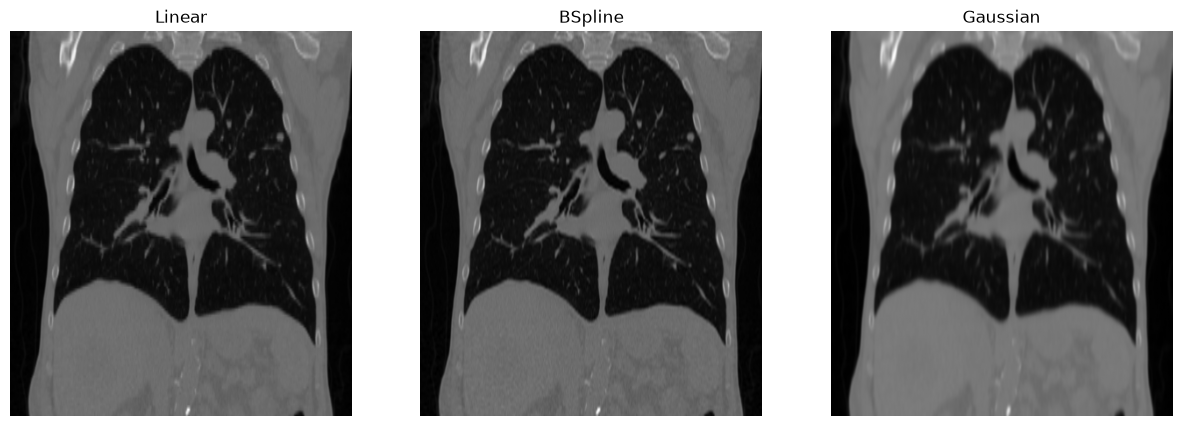

In [64]:
##Attempt #2 with aspect and extent 

plt.figure(figsize=(15, 5))

for i, (name, img) in enumerate(outputs.items()):

    array = sitk.GetArrayFromImage(img)

    plt.subplot(1, 3, i + 1)
    plt.imshow(array[:,200,:], cmap = 'gray', origin = 'lower', aspect= 'auto', extent = (-0.5, 6.5, -0.5, 5.5))
    plt.title(name)
    plt.axis("off")

plt.show()